In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time

In [2]:
class PyTorchNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

In [4]:
import numpy as np
from sklearn.datasets import fetch_openml

# Load MNIST
mnist = fetch_openml(
    name="mnist_784",
    version=1,
    as_frame=False
)

X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.int64)

# Train/test split
X_train = X[:60000]
y_train_labels = y[:60000]

X_test = X[60000:]
y_test_labels = y[60000:]

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_labels, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_labels, dtype=torch.long)

In [6]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

In [7]:
class PyTorchNetwork(nn.Module):

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.network(x)

In [8]:
model_torch = PyTorchNetwork()

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model_torch.parameters(),
    lr=0.01
)

In [9]:
start_time = time.time()

torch_losses = []

for epoch in range(5):

    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model_torch(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_loader)

    torch_losses.append(average_loss)

    print(
        f"Epoch {epoch + 1}/5 - "
        f"Loss: {average_loss:.4f}"
    )

torch_training_time = time.time() - start_time

print(f"\nPyTorch training time: {torch_training_time:.2f} seconds")

Epoch 1/5 - Loss: 1.2476
Epoch 2/5 - Loss: 0.4917
Epoch 3/5 - Loss: 0.3905
Epoch 4/5 - Loss: 0.3491
Epoch 5/5 - Loss: 0.3241

PyTorch training time: 44.74 seconds


In [10]:
with torch.no_grad():

    outputs = model_torch(X_test_tensor)

    predictions_torch = torch.argmax(
        outputs,
        dim=1
    )

    accuracy_torch = (
        predictions_torch == y_test_tensor
    ).float().mean()

print(f"PyTorch Test Accuracy: {accuracy_torch.item():.4f}")

PyTorch Test Accuracy: 0.9162


In [13]:
def one_hot_encode(y, num_classes=10):
    encoded = np.zeros((y.shape[0], num_classes))
    encoded[np.arange(y.shape[0]), y] = 1
    return encoded

In [14]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.network import NeuralNetwork

model_numpy = NeuralNetwork()

start_time = time.time()

history_numpy = model_numpy.train(
    X_train,
    one_hot_encode(y_train_labels),
    epochs=5,
    batch_size=64,
    learning_rate=0.01
)

numpy_training_time = time.time() - start_time

numpy_accuracy = model_numpy.accuracy(
    X_test,
    y_test_labels
)

print(f"\nNumPy Test Accuracy: {numpy_accuracy:.4f}")
print(f"NumPy training time: {numpy_training_time:.2f} seconds")

Epoch 1/5 - Loss: 1.8393
Epoch 2/5 - Loss: 0.6877
Epoch 3/5 - Loss: 0.4628
Epoch 4/5 - Loss: 0.3928
Epoch 5/5 - Loss: 0.3574

NumPy Test Accuracy: 0.9070
NumPy training time: 43.29 seconds


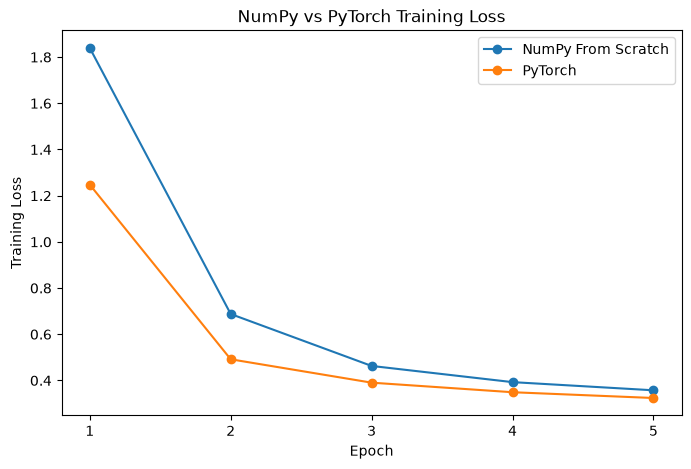

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 6),
    history_numpy["loss"],
    marker="o",
    label="NumPy From Scratch"
)

plt.plot(
    range(1, 6),
    torch_losses,
    marker="o",
    label="PyTorch"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("NumPy vs PyTorch Training Loss")
plt.legend()
plt.xticks(range(1, 6))
plt.show()

In [18]:
import pandas as pd
comparison = pd.DataFrame({
    "Implementation": [
        "NumPy From Scratch",
        "PyTorch"
    ],
    "Test Accuracy": [
        numpy_accuracy,
        accuracy_torch.item()
    ],
    "Training Time (seconds)": [
        numpy_training_time,
        torch_training_time
    ]
})

comparison

,Implementation,Test Accuracy,Training Time (seconds)
0,NumPy From Scratch,0.9070,43.289844
1,PyTorch,0.9162,44.740927


In [19]:
comparison.to_csv(
    "../results/model_comparison.csv",
    index=False
)

print("Comparison saved successfully.")

Comparison saved successfully.


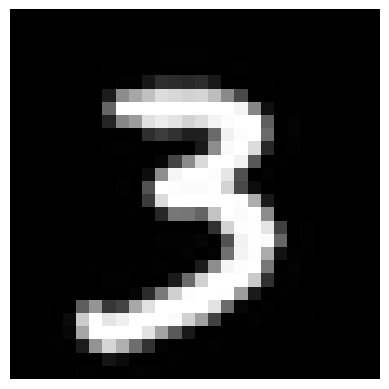

In [20]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

image_path = "../data/test_digits/digit_3.png"

image = Image.open(image_path).convert("L")

plt.imshow(image, cmap="gray")
plt.axis("off")
plt.show()

In [21]:
image_array = np.array(image).astype(np.float32)

image_array = image_array / 255.0

image_array = image_array.reshape(1, 784)

print("Image shape:", image_array.shape)
print("Min:", image_array.min())
print("Max:", image_array.max())

Image shape: (1, 784)
Min: 0.0
Max: 1.0


In [22]:
prediction_numpy = model_numpy.predict(image_array)

print("NumPy Prediction:", prediction_numpy[0])

NumPy Prediction: 3


In [23]:
image_tensor = torch.tensor(
    image_array,
    dtype=torch.float32
)

with torch.no_grad():
    output = model_torch(image_tensor)
    prediction_torch = torch.argmax(output, dim=1)

print("PyTorch Prediction:", prediction_torch.item())

PyTorch Prediction: 3


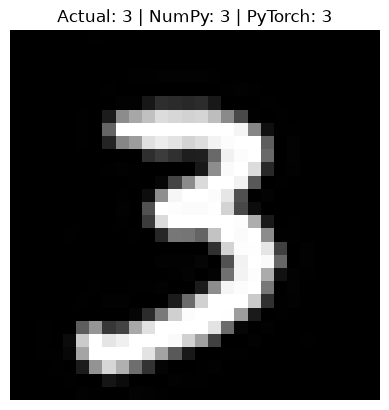

In [24]:
plt.imshow(image_array.reshape(28, 28), cmap="gray")

plt.title(
    f"Actual: 3 | "
    f"NumPy: {prediction_numpy[0]} | "
    f"PyTorch: {prediction_torch.item()}"
)

plt.axis("off")
plt.show()

In [25]:
for digit in range(10):

    image_path = f"../data/test_digits/digit_{digit}.png"

    image = Image.open(image_path).convert("L")

    image_array = np.array(image).astype(np.float32)
    image_array = image_array / 255.0
    image_array = image_array.reshape(1, 784)

    numpy_prediction = model_numpy.predict(image_array)[0]

    image_tensor = torch.tensor(
        image_array,
        dtype=torch.float32
    )

    with torch.no_grad():
        output = model_torch(image_tensor)
        torch_prediction = torch.argmax(output, dim=1).item()

    print(
        f"Actual: {digit} | "
        f"NumPy: {numpy_prediction} | "
        f"PyTorch: {torch_prediction}"
    )

Actual: 0 | NumPy: 0 | PyTorch: 0
Actual: 1 | NumPy: 1 | PyTorch: 1
Actual: 2 | NumPy: 2 | PyTorch: 2
Actual: 3 | NumPy: 3 | PyTorch: 3
Actual: 4 | NumPy: 4 | PyTorch: 4
Actual: 5 | NumPy: 5 | PyTorch: 5
Actual: 6 | NumPy: 6 | PyTorch: 6
Actual: 7 | NumPy: 7 | PyTorch: 7
Actual: 8 | NumPy: 8 | PyTorch: 8
Actual: 9 | NumPy: 9 | PyTorch: 9
